# Voronoi diagrams and point location

For a finite site set $S \subset \mathbb{Q}^2$ and $1 \le k < n = |S|$, the
order-$k$ Voronoi diagram partitions the plane by which $k$-subset of $S$ is
nearest: the cell of $T \subseteq S$, $|T| = k$, is

$$V_k(T) = \{x : \max_{t \in T} |x - t| \le \min_{s \in S \setminus T} |x - s|\},$$

an intersection of half-planes bounded by bisectors, hence convex. Order 1 is the
Voronoi diagram, dual to the Delaunay triangulation; order $n - 1$ is the
farthest-point diagram up to complementing the labels.

Each diagram comes back as a doubly connected edge list whose faces are labeled
with the sites that own them. A nearest-$k$ query is therefore a planar point
location followed by a label read — `diagram.label(diagram.locateFace(q))` — and
after `buildPointLocation()` (a randomized trapezoidal map) the location takes
expected $O(\log E)$ time. Everything is exact: the diagram's vertices are
circumcenters of rational sites, hence rational, so a query on a cell boundary is
*decided* to be one, and the ties can be enumerated rather than guessed at.

The notebook takes one query point $q$ through four structures — the Delaunay
triangulation, the Voronoi diagram, the order-2 diagram and the farthest-point
diagram — drawing in each the cell containing $q$ and oriented segments from $q$
to the site or sites representing that cell. Every answer is checked against
brute force.

In [1]:
from fractions import Fraction
import pypgl as pgl

pgl.REPR_SVG_SIZE = 300

coords = [8,12, 24,38, 45,10, 68,22, 84,48, 58,68, 31,70,
          47,43, 72,54, 14,58, 92,14, 36,24, 60,40, 96,70]
sites = [pgl.Point(coords[i], coords[i + 1]) for i in range(0, len(coords), 2)]
n = len(sites)

q = pgl.Point(Fraction(99, 2), Fraction(91, 3))


def sq(a, b):
    return (a.x() - b.x())**2 + (a.y() - b.y())**2


def by_distance(x):
    '''The sites, nearest to x first -- the brute-force reference.'''
    return sorted(sites, key=lambda s: sq(s, x))


WINDOW = pgl.Rectangle(pgl.Point(-4, 0), pgl.Point(108, 82))


def figure(*layers, window=WINDOW, size=(760, 560)):
    '''Draw (shape, stroke, fill, stroke width) layers onto one canvas framed by window.'''
    canvas = pgl.Canvas().size(*size).margin(10).view(window)
    for shape, stroke, fill, width in layers:
        canvas.stroke(stroke).fill(fill).strokeWidth(width).draw(shape)
    return canvas


EDGES, SITES, QUERY, TO_REP = "#64748b", "#1e3a8a", "#dc2626", "#d97706"


def base(edges):
    return [(edges, EDGES, "none", 1.5), (sites, SITES, SITES, 1)]


def query(*representatives):
    return [([pgl.OrientedSegment(q, r) for r in representatives], TO_REP, "none", 2),
            (q, QUERY, QUERY, 1)]


print(f"{n} sites, {len(pgl.convexHull(sites))} on the hull; q = {q}")

14 sites, 6 on the hull; q = (99/2,91/3)


## The Delaunay triangulation

The triangulation of $S$ in which every triangle's circumdisk has no site in its
interior. The property is checked exactly over all triangles below, together with
general position — no site on a circumcircle other than the triangle's own three
— which is what makes the triangulation, and every diagram after it, unique.

`locate` walks the mesh to the triangle containing $q$. Its three vertices are
the natural representatives of that cell, and they are drawn as such. The segment
in blue is the one to the true nearest site.

20 triangles, 33 edges
q lies in <(36,24)(68,22)(60,40)>
nearest site (47,43) is a vertex of that triangle: False


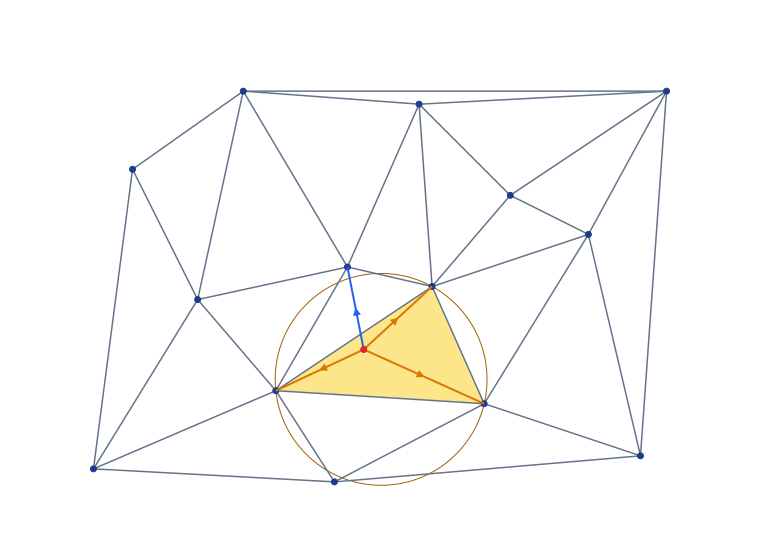

In [2]:
delaunay = pgl.Triangulation(sites)
triangles = delaunay.triangles()

assert not any(t.circumcircle().interiorContains(s) for t in triangles for s in sites)
assert sum(t.circumcircle().boundaryContains(s) for t in triangles for s in sites) == 3 * len(triangles)

located = delaunay.locate(q)
nearest = by_distance(q)[0]
assert nearest not in list(located) and not located.circumcircle().contains(nearest)

print(f"{delaunay.numTriangles()} triangles, {delaunay.numEdges()} edges")
print("q lies in", located)
print("nearest site", nearest, "is a vertex of that triangle:", nearest in list(located))

figure((located, "none", "#fde68a", 0),
       (located.circumcircle(), "#a16207", "none", 1),
       *base(delaunay.edges()),
       (pgl.OrientedSegment(q, nearest), "#2563eb", "none", 2),
       *query(*located))

The nearest site is not a vertex of the triangle containing $q$: it lies outside
that triangle's circumcircle, as the empty-circle property requires, yet closer
to $q$ than any of the three corners. Point location in the Delaunay
triangulation is not a nearest-neighbor query. The dual is.

## The Voronoi diagram

With the sites in general position the duality is exact, and it can be read off
the counts: one Voronoi vertex per Delaunay triangle (its circumcenter), one
Voronoi edge per Delaunay edge (a bisector piece), one cell per site. The cell
containing $q$ is labeled with $q$'s nearest site, and nothing needs to be
searched once the face is found.

Cells are drawn through `halfplaneIntersection(face)`, which for a convex face is
the face itself, bounded or not. The brute-force check is repeated over a grid of
queries, skipping the ones `locateCell` reports on an edge or a vertex, where the
answer ties.

Arrangement(vertices=20, edges=33, faces=14)
q is in the cell of (47,43)
3832 grid queries in an open cell, all matching brute force; 18 on the diagram, skipped


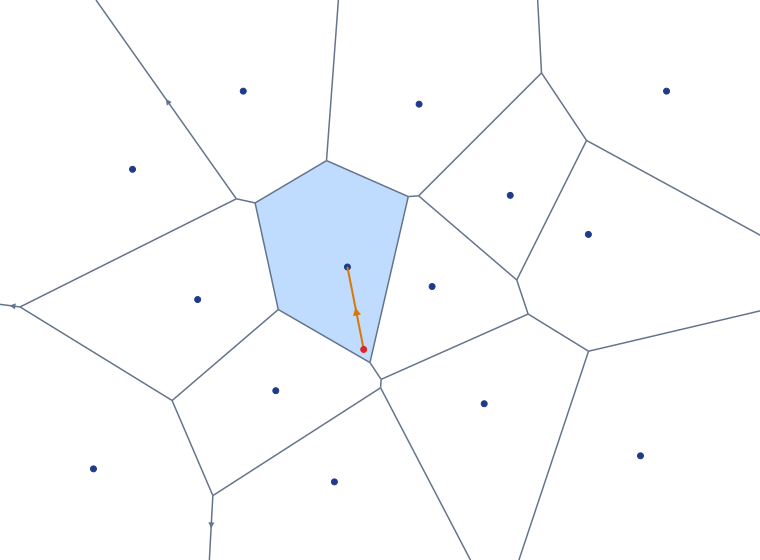

In [3]:
voronoi = pgl.voronoiDiagram(sites)
voronoi.buildPointLocation()

assert (voronoi.vertexCount(), voronoi.edgeCount(), voronoi.faceCount()) == \
       (delaunay.numTriangles(), delaunay.numEdges(), n)

cell = voronoi.locateFace(q)
assert isinstance(voronoi.locateCell(q), pgl.FaceId)
assert voronoi.label(cell) == nearest

grid = [pgl.Point(Fraction(x, 2), Fraction(y, 2)) for x in range(0, 210, 3) for y in range(0, 164, 3)]
checked = 0
for p in grid:
    if isinstance(voronoi.locateCell(p), pgl.FaceId):
        assert voronoi.label(voronoi.locateFace(p)) == by_distance(p)[0]
        checked += 1

print(voronoi)
print(f"q is in the cell of {voronoi.label(cell)}")
print(f"{checked} grid queries in an open cell, all matching brute force; {len(grid) - checked} on the diagram, skipped")

figure((voronoi.halfplaneIntersection(cell), "none", "#bfdbfe", 0),
       *base(voronoi.edges()),
       *query(voronoi.label(cell)))

## The order-2 diagram

A pair $\{a, b\}$ owns a nonempty order-2 cell exactly when $a$ and $b$ are
Voronoi neighbors: on the relative interior of their common Voronoi edge both are
nearest, and a small move off it keeps them the two nearest. So in general
position the order-2 cells are in bijection with the Delaunay edges, and the
assertion below compares the two sets outright.

`voronoiDiagram(sites, k)` builds the order-$k$ diagram by Lee's refinement, and
labels each face with its $k$ sites in their order in the input list. The two
representatives of $q$'s cell are its two nearest sites. The nearest one, from
the previous section, is always among them.

PointListArrangement(vertices=52, edges=84, faces=33)
q is in the cell of [(47,43), (60,40)]


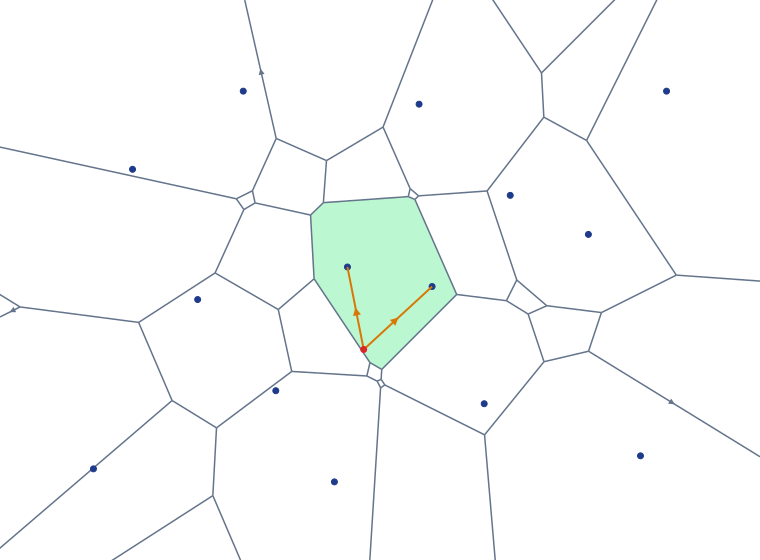

In [4]:
order2 = pgl.voronoiDiagram(sites, 2)
order2.buildPointLocation()

owners = {frozenset(order2.label(pgl.FaceId(f))) for f in range(order2.faceCount())}
assert owners == {frozenset((e.min(), e.max())) for e in delaunay.edges()}

cell2 = order2.locateFace(q)
pair = order2.label(cell2)
assert isinstance(order2.locateCell(q), pgl.FaceId)
assert set(pair) == set(by_distance(q)[:2]) and nearest in pair

print(order2)
print("q is in the cell of", pair)

figure((order2.halfplaneIntersection(cell2), "none", "#bbf7d0", 0),
       *base(order2.edges()),
       *query(*pair))

## The farthest-point diagram

Each face is labeled with the site *farthest* from it. A site is farthest from
some point only if it is a vertex of the convex hull, and then its cell is
unbounded, so the diagram is a tree of segments and rays: $h$ cells, $h - 2$
vertices and $2h - 3$ edges for $h$ hull vertices in general position.

The smallest enclosing disk lives on this tree. Its center minimizes the distance
to the farthest site, so it is either a vertex of the diagram (three sites on the
circle) or a point on an edge (two antipodal sites). `locateCell` says which. It
cannot be inside a face, where the one farthest site could be approached.

Arrangement(vertices=4, edges=9, faces=6)
q is in the cell of (96,70)
the enclosing disk's center lies on a HalfedgeId as the midpoint of (8,12) and (96,70)


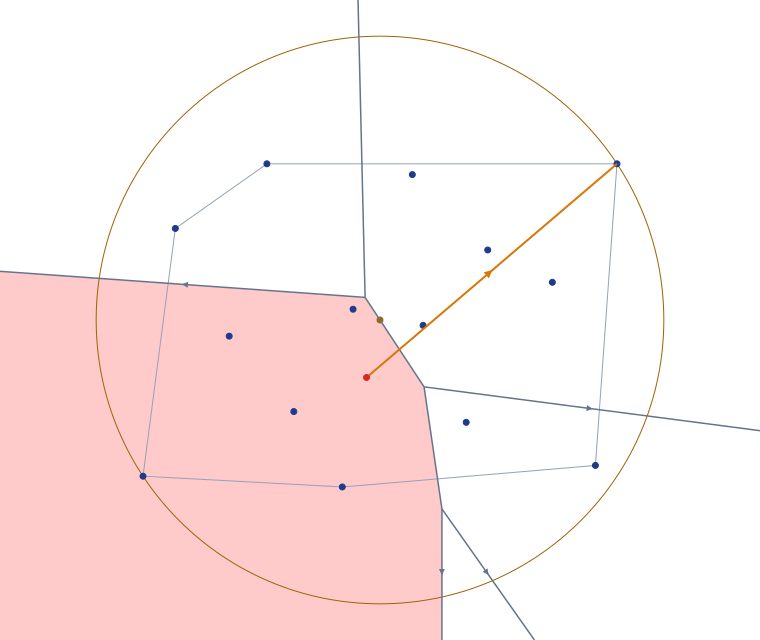

In [5]:
farthest = pgl.farthestVoronoiDiagram(sites)
farthest.buildPointLocation()
hull = pgl.convexHull(sites)
h = len(hull)

assert {farthest.label(pgl.FaceId(f)) for f in range(farthest.faceCount())} == set(hull)
assert (farthest.faceCount(), farthest.vertexCount(), farthest.edgeCount()) == (h, h - 2, 2*h - 3)
assert all(farthest.isUnbounded(pgl.FaceId(f)) for f in range(farthest.faceCount()))

cell_far = farthest.locateFace(q)
assert farthest.label(cell_far) == by_distance(q)[-1]

enclosing = pgl.smallestEnclosingDisk(sites)
center_cell = farthest.locateCell(enclosing.center())
assert isinstance(center_cell, pgl.HalfedgeId)
a, b = (s for s in sites if enclosing.boundaryContains(s))
assert pgl.Segment(a, b).midpoint() == enclosing.center()

print(farthest)
print("q is in the cell of", farthest.label(cell_far))
print("the enclosing disk's center lies on a", type(center_cell).__name__, "as the midpoint of", a, "and", b)

figure((farthest.halfplaneIntersection(cell_far), "none", "#fecaca", 0),
       (pgl.Polygon(hull), "#94a3b8", "none", 1),
       (enclosing, "#a16207", "none", 1),
       (enclosing.center(), "#a16207", "#a16207", 1),
       *base(farthest.edges()),
       *query(farthest.label(cell_far)),
       window=pgl.Rectangle(pgl.Point(-12, -16), pgl.Point(116, 98)), size=(760, 640))

The center lies on an edge. The circle passes through two sites, and they are
antipodal on it.

The farthest-point diagram is the order-$(n-1)$ diagram with its labels
complemented: the $n - 1$ nearest sites are all but the farthest one. The two
constructions share nothing, which makes the identity a useful cross-check.

In [6]:
order_last = pgl.voronoiDiagram(sites, n - 1)
assert order_last.faceCount() == farthest.faceCount()

for p in grid:
    if isinstance(farthest.locateCell(p), pgl.FaceId):
        rest = set(order_last.label(order_last.locateFace(p)))
        assert rest == set(sites) - {farthest.label(farthest.locateFace(p))}

print(order_last)

PointListArrangement(vertices=4, edges=9, faces=6)


## Ties

A query on a diagram edge or vertex is equidistant from several sites, and
`locateFace` resolves it by a symbolic perturbation to one of the tied faces.
`locateCell` does not perturb: it names the vertex, edge or face that contains
the point, and the faces around a vertex name every tied site. At a Voronoi
vertex, those are the three sites on its empty circle.

Voronoi vertex (1766/35,991/35) is VertexId(19)
equidistant sites: [(36,24), (47,43), (60,40)] at squared distance 278837/1225


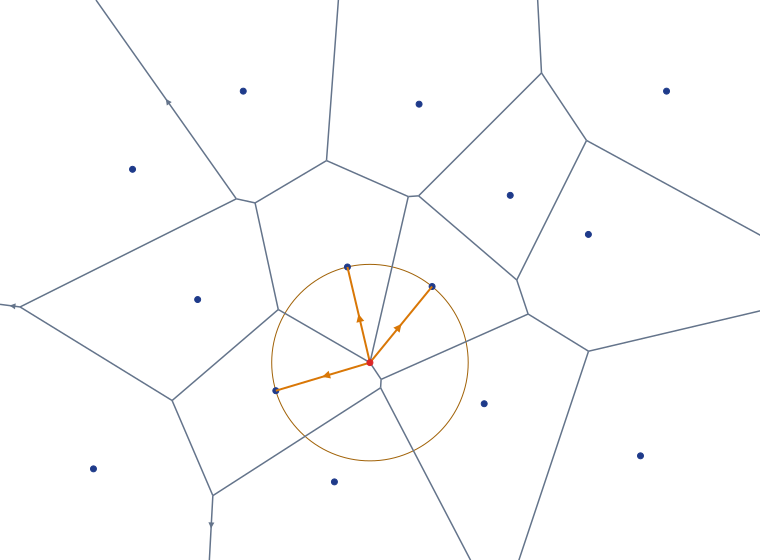

In [7]:
corners = {voronoi.source(he) for he in voronoi.boundaryOf(cell)} - {pgl.VertexId(voronoi.vertexCount())}
corner = min(corners, key=lambda v: sq(voronoi.position(v), q))
c = voronoi.position(corner)

located_corner = voronoi.locateCell(c)
assert located_corner == corner

tied = sorted({voronoi.label(voronoi.face(he)) for he in voronoi.outgoingHalfedges(corner)})
assert len(tied) == 3 and len({sq(s, c) for s in tied}) == 1
assert sq(tied[0], c) == sq(by_distance(c)[0], c)

print("Voronoi vertex", c, "is", located_corner)
print("equidistant sites:", tied, "at squared distance", sq(tied[0], c))

figure((pgl.Disk(*tied), "#a16207", "none", 1),
       *base(voronoi.edges()),
       ([pgl.OrientedSegment(c, s) for s in tied], TO_REP, "none", 2),
       (c, QUERY, QUERY, 1))